# scWAT Xenium QC Region3
## Xiaonan Wang
## 18Aug2026

## Setup

### Parameters

Change `REGION_ID` for manual execution. Launchers inject the same parameters without editing the source notebook.

In [1]:
PROJECT_ROOT <- "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium"
PIPELINE_REPO <- file.path(PROJECT_ROOT, "adipose_analysis", "YNH_Xenium_scWAT")
INPUT_ROOT <- file.path(PROJECT_ROOT, "adipose_data")
REGION_ID <- "Region_3"
RUN_LABEL <- "full_notebook_qc_v2"
METADATA_PATH <- file.path(PIPELINE_REPO, "config", "scwat_sample_manifest.tsv")
EXPECTED_SECTION_COUNT <- 4L
SEED <- 20260814L
STRICT_MODE <- FALSE
EXTENDED_QC_MODE <- "AUTO"
EXTENDED_QC_CONFIG_PATH <- file.path(PIPELINE_REPO, "config", "extended_qc_defaults.tsv")
FIXED_CELL_QC_THRESHOLDS_PATH <- file.path(PIPELINE_REPO, "config", "fixed_cell_qc_thresholds.tsv")


In [2]:
OUTPUT_ROOT <- file.path(PROJECT_ROOT, "adipose_analysis", "scwat_qc_outputs", RUN_LABEL)
SECTION_OUTPUT_DIR <- file.path(OUTPUT_ROOT, "sections", REGION_ID)

In [3]:
source(file.path(PIPELINE_REPO, "R", "source.R"))
fixed_thresholds <- read_fixed_cell_qc_thresholds(FIXED_CELL_QC_THRESHOLDS_PATH)


In [4]:
for (package in c("Matrix", "jsonlite", "ggplot2")) require_package(package)

In [5]:
dir.create(SECTION_OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)
stopifnot(REGION_ID %in% paste0("Region_", seq_len(EXPECTED_SECTION_COUNT)))
cat("Section:", REGION_ID, "\nOutput:", SECTION_OUTPUT_DIR, "\n")

Section: Region_3 
Output: /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3 


## Inputs

The selected raw/subset section directory is discovered by region ID. 

In [6]:
all_sections <- discover_xenium_sections(INPUT_ROOT, EXPECTED_SECTION_COUNT)

In [7]:
all_sections

region_id,region_number,region_dir
<chr>,<int>,<chr>
Region_1,1,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_1__20260805__124712
Region_2,2,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_2__20260805__124712
Region_3,3,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_3__20260805__124712
Region_4,4,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_4__20260805__124712


In [8]:
selected_section <- discover_one_section(INPUT_ROOT, REGION_ID)
selected_section

region_id,region_number,region_dir
<chr>,<int>,<chr>
Region_3,3,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_3__20260805__124712


## Step1 - Configuration and metadata contract

In [9]:
if (nzchar(METADATA_PATH)) {
  assert_path_within(PROJECT_ROOT, METADATA_PATH)
  full_manifest <- utils::read.delim(METADATA_PATH, check.names = FALSE)
} else {
  full_manifest <- create_synthetic_manifest(all_sections$region_id, SEED)
}

In [10]:
full_manifest

tissue,region_id,mouse_id,section_id,biological_replicate_id,technical_replicate_id,genotype,treatment,condition,age_weeks,metadata_status,do_not_interpret,notes
<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>
scWAT,Region_1,Mouse_1,62308,Mouse_1,Region_1,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62308; no left/right factor
scWAT,Region_2,Mouse_1,62309,Mouse_1,Region_2,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62309; no left/right factor
scWAT,Region_3,Mouse_2,62310,Mouse_2,Region_3,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62310; no left/right factor
scWAT,Region_4,Mouse_2,62311,Mouse_2,Region_4,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62311; no left/right factor


In [11]:
# manifest_check <- validate_sample_manifest(full_manifest, all_sections$region_id)
# if (!manifest_check$valid) stop(paste(manifest_check$issues, collapse = "; "))

In [12]:
section_manifest <- full_manifest[full_manifest$region_id == REGION_ID, , drop = FALSE]
section_manifest$region_dir <- selected_section$region_dir

In [13]:
section_manifest

,tissue,region_id,mouse_id,section_id,biological_replicate_id,technical_replicate_id,genotype,treatment,condition,age_weeks,metadata_status,do_not_interpret,notes,region_dir
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>,<chr>
3,scWAT,Region_3,Mouse_2,62310,Mouse_2,Region_3,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62310; no left/right factor,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_3__20260805__124712


In [14]:
configuration <- data.frame(
  key = c("project_root", "pipeline_repo", "input_root", "output_root", "region_id", "run_label", "seed", "strict_mode"),
  value = c(PROJECT_ROOT, PIPELINE_REPO, INPUT_ROOT, OUTPUT_ROOT, REGION_ID, RUN_LABEL, SEED, STRICT_MODE)
)

In [15]:
configuration

key,value
<chr>,<chr>
project_root,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium
pipeline_repo,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/YNH_Xenium_scWAT
input_root,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data
output_root,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2
region_id,Region_3
run_label,full_notebook_qc_v2
seed,20260814
strict_mode,FALSE


In [16]:
environment <- data.frame(
  item = c("R_version", "platform", "tempdir", "Matrix", "jsonlite", "ggplot2"),
  value = c(R.version.string, R.version$platform, tempdir(), as.character(packageVersion("Matrix")), as.character(packageVersion("jsonlite")), as.character(packageVersion("ggplot2")))
)

In [17]:
environment

item,value
<chr>,<chr>
R_version,R version 4.5.3 (2026-03-11)
platform,x86_64-conda-linux-gnu
tempdir,/tmp/RtmpMkZ0aj
Matrix,1.7.6
jsonlite,2.0.0
ggplot2,4.0.3


## Step2 - Provenance, integrity, panel reconciliation, and QC gate

In [18]:
region_dir <- selected_section$region_dir[[1]]
inventory <- inventory_section_files(region_dir, REGION_ID, calculate_md5 = TRUE)

In [19]:
inventory

region_id,relative_path,exists,size_bytes,modified_utc,md5
<chr>,<chr>,<lgl>,<dbl>,<chr>,<chr>
Region_3,experiment.xenium,TRUE,2780,2026-08-13 14:31:48 UTC,fbccc7fa4da766a0186fa67bb894bdba
Region_3,metrics_summary.csv,TRUE,2199,2026-08-13 14:31:48 UTC,9c6972afdfac5833630270ec3b94bc11
Region_3,analysis_summary.html,TRUE,8491741,2026-08-13 14:31:09 UTC,302224cdcaae0f1155b996210db36063
Region_3,gene_panel.json,TRUE,256874,2026-08-13 14:31:50 UTC,88b3b1dc6443d266a7419c2b129e31b7
Region_3,cells.csv.gz,TRUE,4486945,2026-08-13 14:31:06 UTC,aa7e3d97758be30c1788496745f010c1
Region_3,cell_feature_matrix/features.tsv.gz,TRUE,4272,2026-08-13 15:24:17 UTC,0570f7c8310c95bd778ad0572716db8e
Region_3,cell_feature_matrix/barcodes.tsv.gz,TRUE,335650,2026-08-13 15:24:18 UTC,9779e010bbeeeedcc668c54506af0a86
Region_3,cell_feature_matrix/matrix.mtx.gz,TRUE,26076321,2026-08-13 15:24:37 UTC,6baf4f3af16b535104953bd4583e92ac


In [20]:
# if (!all(inventory$exists)) stop(paste("Missing required files:", paste(inventory$relative_path[!inventory$exists], collapse = ", ")))

In [21]:
# check 
## matrix.mtx.gz
## features.tsv.gz
## barcodes.tsv.gz
## cells.csv.gz
integrity <- validate_section_integrity(region_dir, REGION_ID)

In [22]:
integrity

region_id,matrix_features,matrix_cells,matrix_nonzero,feature_rows,barcode_rows,cell_rows,duplicate_cell_ids,dimension_match
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>
Region_3,541,75957,5420031,541,75957,75957,0,TRUE


In [23]:
alarms <- extract_analysis_alarms(file.path(region_dir, "analysis_summary.html"))

In [24]:
alarms

raw_value,formatted_value,raised,title,message,level,id
<lgl>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>


In [25]:
# Gene gene annotations - from yanan
signature <- utils::read.delim(file.path(PIPELINE_REPO, "config", "eos_gene_sets.tsv"), check.names = FALSE)
gene_sets <- setNames(signature$gene_set, signature$gene)

In [26]:
table(signature$gene_set)


     common  long_lived short_lived 
          7          46          47 

In [27]:
nrow(signature)

[1] 100

In [28]:
# from xenium output
installed_genes <- read_custom_panel_genes(file.path(region_dir, "gene_panel.json"))

In [29]:
length(installed_genes)

[1] 100

In [30]:
# check if all match
panel_reconciliation <- reconcile_panel(signature$gene, installed_genes, gene_sets)

In [31]:
table(panel_reconciliation$status)


MATCH 
  100 

In [32]:
features_preview <- read_xenium_features(file.path(region_dir, "cell_feature_matrix", "features.tsv.gz"))

In [33]:
head(features_preview)

,feature_id,feature_name,feature_type
,<chr>,<chr>,<chr>
1,ENSMUSG00000109644,0610005C13Rik,Gene Expression
2,ENSMUSG00000028441,1110017D15Rik,Gene Expression
3,ENSMUSG00000096001,2610528A11Rik,Gene Expression
4,ENSMUSG00000040412,5330417C22Rik,Gene Expression
5,ENSMUSG00000018451,6330403K07Rik,Gene Expression
6,ENSMUSG00000109321,A330076H08Rik,Gene Expression


In [34]:
dim(features_preview)

[1] 541   3

In [35]:
feature_type_summary <- as.data.frame(table(features_preview$feature_type), stringsAsFactors = FALSE)
names(feature_type_summary) <- c("feature_type", "n_features")

In [36]:
feature_type_summary

feature_type,n_features
<chr>,<int>
Gene Expression,479
Negative Control Codeword,41
Negative Control Probe,20
Unassigned Codeword,1


## Step3 - Sparse import and section-specific cell QC

In [37]:
# read in 
## features.tsv.gz
## barcodes.tsv.gz
## matrix.mtx.gz
## cells.csv.gz
xenium <- import_xenium_mex(region_dir)

In [38]:
head(xenium$cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<chr>
aaaacgbo-1,aaaacgbo-1,1207.875,2257.219,146,0,0,0,0,0,146,50.89110,34.95094,1,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin)
aaacfimf-1,aaacfimf-1,1188.792,2288.468,312,0,0,0,0,0,312,78.48157,50.89110,1,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin)


In [39]:
table(xenium$cells$segmentation_method)


Segmented by boundary stain (ATP1A1+CD45+E-Cadherin) 
                                               21630 
                   Segmented by interior stain (18S) 
                                               53397 
             Segmented by nucleus expansion of 5.0µm 
                                                 930 

In [40]:
table(xenium$cells$nucleus_count)


    0     1     2     3     4 
 1673 73211  1029    40     4 

In [41]:
xenium$raw_matrix_dimensions

features    cells  nonzero 
     541    75957  5420031

In [42]:
xenium$raw_matrix_dimensions[3]*100/(xenium$raw_matrix_dimensions[1]*xenium$raw_matrix_dimensions[2])

nonzero 
13.18975

### Prespecified core cell-QC rule

A cell passes `qc_core_pass` only when both strict open intervals hold:

- `5 < nFeature_Xenium < 200`
- `10 < nCount_Xenium < 1000`

Values exactly equal to 5, 200, 10, or 1000 fail. Robust distribution limits remain diagnostic only and do not redefine this cohort.


In [43]:
qc <- calculate_xenium_cell_qc(
  xenium$counts, xenium$cells, REGION_ID,
  fixed_thresholds = fixed_thresholds
)
metadata_columns <- intersect(c("mouse_id", "side", "section_id", "biological_replicate_id", "genotype", "treatment", "condition", "age_weeks", "metadata_status", "do_not_interpret"), names(section_manifest))
for (column in metadata_columns) qc$cell_metadata[[column]] <- section_manifest[[column]][[1]]

In [44]:
qc$thresholds

,region_id,metric,lower,upper,value,method
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
method,Region_3,nCount_Xenium,1,782.6270,197.00000,median_minus_3MAD_plus_5MAD
method1,Region_3,nFeature_Xenium,1,196.0210,70.00000,median_minus_3MAD_plus_5MAD
method2,Region_3,cell_area,0,219.2935,51.25235,median_minus_5MAD_plus_5MAD
1,Region_3,control_fraction_cell,0,0.0500,0.00000,max_5pct_or_q99.5


In [45]:
head(qc$cell_metadata, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,qc_review_flag,mouse_id,section_id,biological_replicate_id,genotype,treatment,condition,age_weeks,metadata_status,do_not_interpret
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<lgl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>
aaaacgbo-1,aaaacgbo-1,1207.875,2257.219,146,0,0,0,0,0,146,⋯,FALSE,Mouse_2,62310,Mouse_2,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE
aaacfimf-1,aaacfimf-1,1188.792,2288.468,312,0,0,0,0,0,312,⋯,FALSE,Mouse_2,62310,Mouse_2,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE


In [46]:
qc$summary

region_id,input_cells,core_qc_pass,core_qc_fail,review_flagged,nucleus_missing,multiple_nuclei,segmentation_multiplet,area_outlier,high_control,cells_deleted
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Region_3,75957,75423,534,4268,1673,1073,1128,1156,5,0


In [47]:
section_plots <- plot_section_qc(qc$cell_metadata, REGION_ID)

In [48]:
options(repr.plot.width=6, repr.plot.height=4)

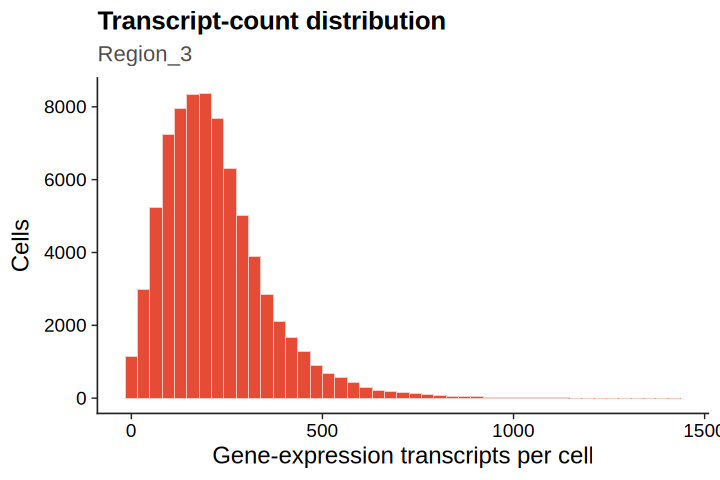

In [49]:
print(section_plots$counts)

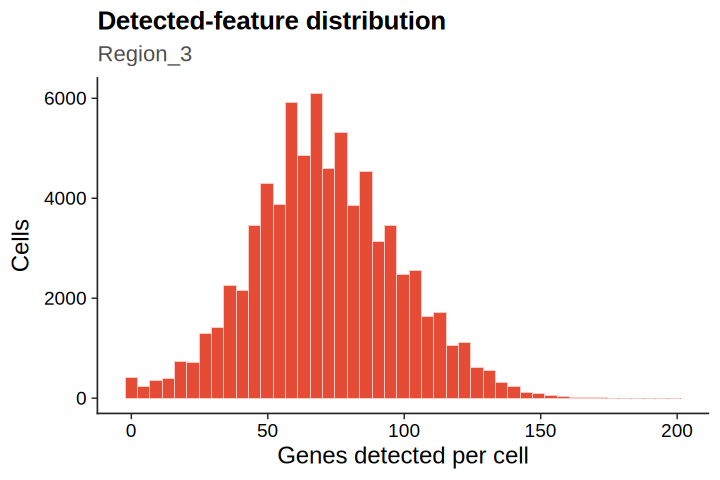

In [50]:
print(section_plots$features)

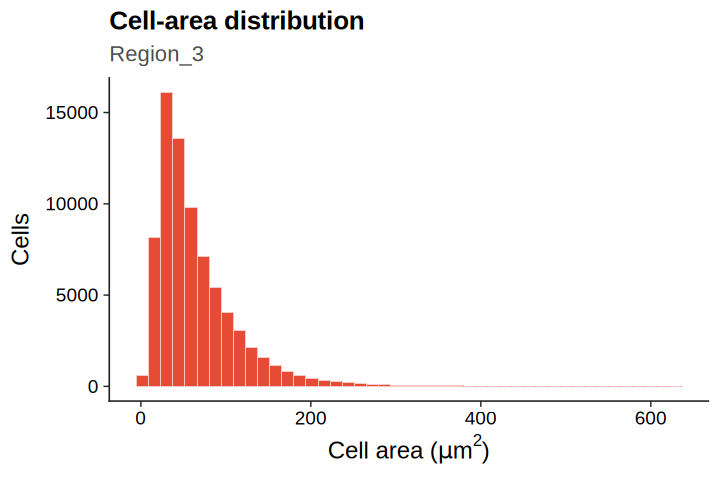

In [51]:
print(section_plots$area)

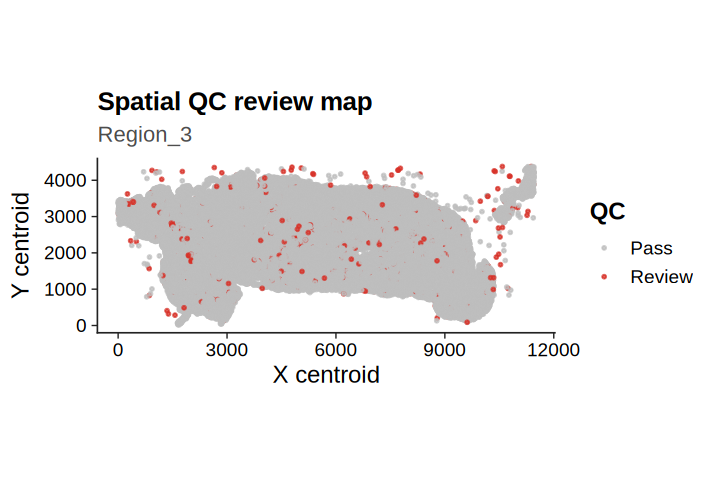

In [52]:
print(section_plots$spatial)

## Step4 - Cycle Alarm Check

In [53]:
extended_config <- read_extended_qc_config(EXTENDED_QC_CONFIG_PATH)

In [54]:
t(as.data.frame(extended_config))

qv_threshold,20.00
spatial_k,15.00
grid_size_um,100.00
permutations,999.00
dense_quantile,0.90
min_bin_cells,20.00
hotspot_fdr,0.05
candidate_abs_log2_ratio,0.50
candidate_abs_q20_delta,0.05
concordance_gene_spearman,0.90
concordance_review_rate_difference,0.05


In [55]:
extended_mode <- resolve_extended_qc_mode(EXTENDED_QC_MODE, region_dir)

In [56]:
extended_mode

[1] "FULL_HPC"

In [57]:
# check package availability
extended_preflight <- extended_qc_preflight(extended_mode, region_dir, extended_config)

In [58]:
extended_preflight

check,required,available,status,details,mode
<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>
transcripts_parquet,TRUE,TRUE,PASS,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_3__20260805__124712/transcripts.parquet,FULL_HPC
arrow,TRUE,TRUE,PASS,R package for projected Parquet aggregation,FULL_HPC
dplyr,TRUE,TRUE,PASS,R package for lazy Arrow grouping and aggregation,FULL_HPC
RANN,TRUE,TRUE,PASS,R package for scalable nearest-neighbour calculations,FULL_HPC


In [59]:
# if (extended_mode == "FULL_HPC" && any(extended_preflight$status == "FAIL")) {
#   stop(paste("FULL_HPC extended preflight failed:", paste(extended_preflight$check[extended_preflight$status == "FAIL"], collapse = ", ")))
# }

In [60]:
cycle_alarm_evidence <- build_cycle_alarm_evidence(alarms, REGION_ID)

In [61]:
cycle_alarm_evidence

region_id,raised,title,message,level,id,evidence_status,cycle_identity_status,gene_effect_status
<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Region_3,FALSE,NA,NA,NA,NA,NO_ALARM_REPORTED,NO_POOR_CYCLE_ALARM_REPORTED,NO_POOR_CYCLE_ALARM_REPORTED


In [62]:
cat("Extended mode:", extended_mode, "\nInput:", region_dir, "\nOutput:", SECTION_OUTPUT_DIR, "\n")

Extended mode: FULL_HPC 
Input: /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_3__20260805__124712 
Output: /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3 


## Step5 - Per-gene quality diagnostics

In [63]:
matrix_gene_quality <- summarise_gene_matrix_qc(xenium$counts, REGION_ID, gene_sets)

In [64]:
head(matrix_gene_quality,n=2)

,region_id,gene,gene_set,raw_counts,counts_per_10000,detected_cells,detection_fraction,matrix_cells
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,Region_3,0610005C13Rik,NA,2104,1.263941,2055,0.02705478,75957
2,Region_3,1110017D15Rik,NA,2305,1.384688,2223,0.02926656,75957


In [65]:
extended_config$qv_threshold

[1] 20

In [66]:
transcript_gene_quality <- data.frame()
# qv: qualiity value
# q20: qv >= qv_threshold, which = 20
if (extended_mode == "FULL_HPC") {
  transcript_gene_quality <- summarise_transcript_quality_arrow(file.path(region_dir, "transcripts.parquet"), REGION_ID, extended_config$qv_threshold)
  gene_quality <- combine_gene_quality(matrix_gene_quality, transcript_gene_quality)
} else {
  gene_quality <- matrix_gene_quality
  gene_quality$transcript_rows <- NA_integer_
  gene_quality$mean_qv <- NA_real_
  gene_quality$fraction_q20 <- NA_real_
  gene_quality$represented_codewords <- NA_integer_
  gene_quality$transcript_status <- "NOT_RUN_LOCAL_SUBSET"
}

In [67]:
head(transcript_gene_quality, n =2)

,region_id,gene,transcript_rows,mean_qv,fraction_q20,represented_codewords,transcript_status
,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<chr>
453,Region_3,0610005C13Rik,4077,26.76269,0.5477066,1,MEASURED_ARROW_PROJECTED_AGGREGATE
196,Region_3,1110017D15Rik,3323,30.20471,0.7330725,1,MEASURED_ARROW_PROJECTED_AGGREGATE


In [68]:
head(gene_quality, n = 2)

,region_id,gene,gene_set,raw_counts,counts_per_10000,detected_cells,detection_fraction,matrix_cells,transcript_rows,mean_qv,fraction_q20,represented_codewords,transcript_status
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<chr>
1,Region_3,0610005C13Rik,NA,2104,1.263941,2055,0.02705478,75957,4077,26.76269,0.5477066,1,MEASURED_ARROW_PROJECTED_AGGREGATE
2,Region_3,1110017D15Rik,NA,2305,1.384688,2223,0.02926656,75957,3323,30.20471,0.7330725,1,MEASURED_ARROW_PROJECTED_AGGREGATE


## Step6 - Spatial diagnostics

In [69]:
extended_config$grid_size_um

[1] 100

In [70]:
spatial_cells <- assign_spatial_grid(qc$cell_metadata, extended_config$grid_size_um)

In [71]:
dim(spatial_cells)

[1] 75957    39

In [72]:
head(spatial_cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,treatment,condition,age_weeks,metadata_status,do_not_interpret,grid_x,grid_y,grid_id,edge_proxy,grid_size_um
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<chr>,<int>,<chr>,<lgl>,<int>,<int>,<chr>,<lgl>,<dbl>
aaaacgbo-1,aaaacgbo-1,1207.875,2257.219,146,0,0,0,0,0,146,⋯,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,12,22,12:22,FALSE,100
aaacfimf-1,aaacfimf-1,1188.792,2288.468,312,0,0,0,0,0,312,⋯,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,11,22,11:22,TRUE,100


In [73]:
spatial_k <- min(as.integer(extended_config$spatial_k), nrow(spatial_cells) - 1L)

In [74]:
spatial_k

[1] 15

In [75]:
spatial_cells$local_density <- calculate_knn_density(spatial_cells, spatial_k, extended_mode)

In [76]:
head(spatial_cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,condition,age_weeks,metadata_status,do_not_interpret,grid_x,grid_y,grid_id,edge_proxy,grid_size_um,local_density
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<int>,<chr>,<lgl>,<int>,<int>,<chr>,<lgl>,<dbl>,<dbl>
aaaacgbo-1,aaaacgbo-1,1207.875,2257.219,146,0,0,0,0,0,146,⋯,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,12,22,12:22,FALSE,100,0.003575454
aaacfimf-1,aaacfimf-1,1188.792,2288.468,312,0,0,0,0,0,312,⋯,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,11,22,11:22,TRUE,100,0.002541728


In [77]:
extended_config$dense_quantile

[1] 0.9

In [78]:
density_cutoff <- stats::quantile(spatial_cells$local_density, extended_config$dense_quantile, na.rm = TRUE)
spatial_cells$dense_aggregate <- spatial_cells$local_density >= density_cutoff

In [79]:
table(spatial_cells$dense_aggregate)


FALSE  TRUE 
68360  7597 

In [80]:
head(spatial_cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,age_weeks,metadata_status,do_not_interpret,grid_x,grid_y,grid_id,edge_proxy,grid_size_um,local_density,dense_aggregate
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<lgl>,<int>,<int>,<chr>,<lgl>,<dbl>,<dbl>,<lgl>
aaaacgbo-1,aaaacgbo-1,1207.875,2257.219,146,0,0,0,0,0,146,⋯,8,VERIFIED_USER_SUPPLIED,FALSE,12,22,12:22,FALSE,100,0.003575454,FALSE
aaacfimf-1,aaacfimf-1,1188.792,2288.468,312,0,0,0,0,0,312,⋯,8,VERIFIED_USER_SUPPLIED,FALSE,11,22,11:22,TRUE,100,0.002541728,FALSE


In [81]:
# if QC flags cluster together?
spatial_global <- test_spatial_flag_clustering(spatial_cells, spatial_k, extended_config$permutations, extended_config$seed, extended_mode)
spatial_global$region_id <- REGION_ID

In [82]:
spatial_global

status,statistic,empirical_p,permutations,k,seed,region_id
<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
ESTIMATED,0.04959762,0.001,999,15,20260814,Region_3


QC-flagged cells in Region 3 are not randomly scattered, they are spatially clustered!

In [83]:
# check spatial enrichment
spatial_edge_density <- summarise_spatial_enrichment(spatial_cells)
spatial_edge_density$region_id <- REGION_ID

In [84]:
spatial_edge_density

class_type,class,cells,flagged,review_rate,risk_ratio,absolute_rate_difference,region_id
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
edge_proxy,edge,4603,265,0.05757115,1.0278122,0.00147058,Region_3
edge_proxy,interior,71354,4003,0.05610057,1.0278122,0.00147058,Region_3
local_density,dense,7597,85,0.01118863,0.1838804,-0.05000213,Region_3
local_density,non_dense,68360,4183,0.06119075,0.1838804,-0.05000213,Region_3


- cells near the tissue edge are about 2% more likely to be QC-flagged than interior cells -> no much edge issue
- dense regions are protective with respect to QC flags, the flag rate is about 82% lower in dense areas than in non-dense areas

Thus, Region 3 QC flags are spatially non-random, no enrichment near tissue edges, and QC flags are not driven by dense cellular regions. The effect size is modest overall.

In [85]:
# find spatial hotspots
spatial_hotspots <- find_spatial_qc_hotspots(spatial_cells, extended_config$permutations, extended_config$min_bin_cells, extended_config$hotspot_fdr, extended_config$seed)
spatial_hotspots$region_id <- rep(REGION_ID, nrow(spatial_hotspots))

In [86]:
dim(spatial_hotspots)

[1] 1337   18

In [87]:
head(spatial_hotspots,n=2)

,grid_id,cells,flagged,review_rate,global_rate,rate_difference,empirical_p,adjusted_p,hotspot_status,x_min,x_max,y_min,y_max,fdr_threshold,min_bin_cells_threshold,permutations,seed,region_id
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
1,12:22,42,4,0.0952381,0.05618969,0.03904841,0.209,0.9376946,NO_HOTSPOT_EVIDENCE,1202.723,1300.580,2221.535,2315.567,0.05,20,999,20260814,Region_3
2,12:21,27,0,0.0000000,0.05618969,-0.05618969,1.000,1.0000000,NO_HOTSPOT_EVIDENCE,1209.420,1301.167,2124.767,2214.335,0.05,20,999,20260814,Region_3


In [88]:
table(spatial_hotspots$hotspot_status)


MORPHOLOGY_REVIEW_REQUIRED        NO_HOTSPOT_EVIDENCE 
                        34                       1303 

In [89]:
manual_review_manifest <- spatial_hotspots[spatial_hotspots$hotspot_status == "MORPHOLOGY_REVIEW_REQUIRED", , drop = FALSE]

In [90]:
dim(manual_review_manifest)

[1] 34 18

In [91]:
# if (!nrow(manual_review_manifest)) manual_review_manifest$review_note <- character() else manual_review_manifest$review_note <- "Inspect morphology/image for edge, fold, tear, or dense aggregate context"

In [92]:
extended_plots <- plot_extended_spatial_qc(spatial_cells, spatial_edge_density, spatial_hotspots, REGION_ID)

In [93]:
names(extended_plots)

[1] "review_map"   "edge_density" "hotspots"

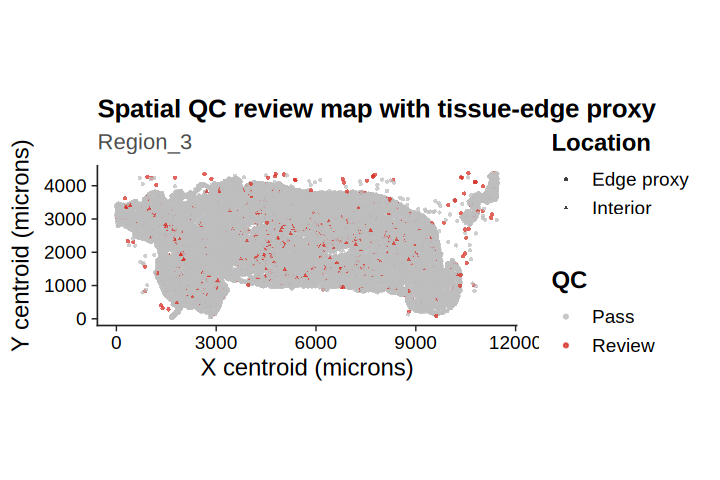

In [94]:
print(extended_plots$review_map)

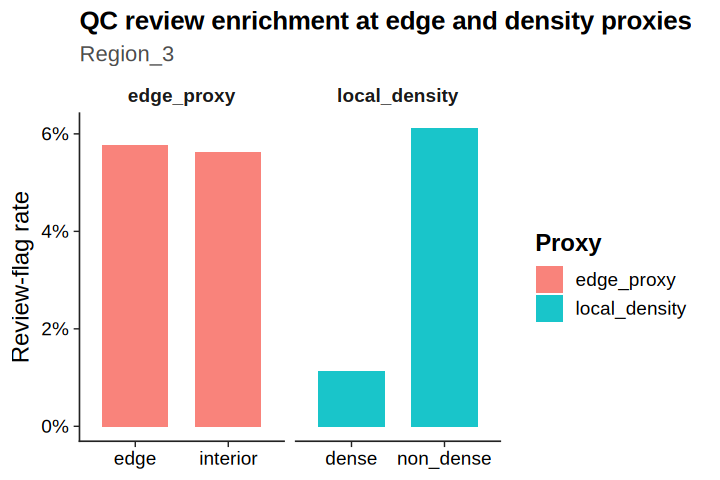

In [95]:
print(extended_plots$edge_density)

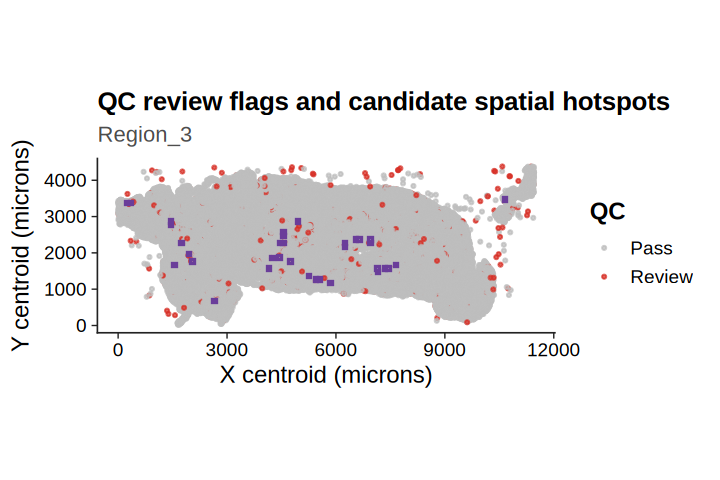

In [96]:
# there is no identified hotspots
print(extended_plots$hotspots)

## Step7 - Evidence-only downstream masks

### Downstream masks (raw objects remain unchanged)

- `primary_include`: exactly `qc_core_pass`, using `5 < nFeature_Xenium < 200` and `10 < nCount_Xenium < 1000`.
- `strict_include`: `primary_include & !qc_review_flag`; this additionally removes cells carrying any nucleus, segmentation, area, control, or core-QC review flag.
- `hotspot_sensitivity_include`: `primary_include` with Region 3 morphology-review hotspot cells excluded.

The primary mask is the main downstream cohort. All flags and all raw cells remain stored for audit and sensitivity analyses.


In [97]:
mask_provenance <- paste(RUN_LABEL, REGION_ID, extended_mode, normalizePath(region_dir, winslash = "/", mustWork = TRUE), sep = "|")

In [98]:
mask_provenance

[1] "full_notebook_qc_v2|Region_3|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_3__20260805__124712"

In [99]:
colnames(spatial_cells)

[1] "cell_id"                     "x_centroid"                 
 [3] "y_centroid"                  "transcript_counts"          
 [5] "control_probe_counts"        "genomic_control_counts"     
 [7] "control_codeword_counts"     "unassigned_codeword_counts" 
 [9] "deprecated_codeword_counts"  "total_counts"               
[11] "cell_area"                   "nucleus_area"               
[13] "nucleus_count"               "segmentation_method"        
[15] "region_id"                   "nCount_Xenium"              
[17] "nFeature_Xenium"             "control_fraction_cell"      
[19] "nucleus_missing_flag"        "multiple_nuclei_flag"       
[21] "cell_area_outlier_flag"      "high_control_flag"          
[23] "segmentation_multiplet_flag" "qc_core_pass"               
[25] "qc_review_flag"              "mouse_id"                   
[27] "section_id"                  "biological_replicate_id"    
[29] "genotype"                    "treatment"                  
[31] "condition"                   "age_weeks"                  
[33] "metadata_status"             "do_not_interpret"           
[35] "grid_x"                      "grid_y"                     
[37] "grid_id"                     "edge_proxy"                 
[39] "grid_size_um"                "local_density"              
[41] "dense_aggregate"

In [100]:
downstream_masks <- build_cell_downstream_masks(spatial_cells, spatial_hotspots, mask_provenance)

In [101]:
colnames(downstream_masks)

[1] "cell_id"                       "x_centroid"                   
 [3] "y_centroid"                    "transcript_counts"            
 [5] "control_probe_counts"          "genomic_control_counts"       
 [7] "control_codeword_counts"       "unassigned_codeword_counts"   
 [9] "deprecated_codeword_counts"    "total_counts"                 
[11] "cell_area"                     "nucleus_area"                 
[13] "nucleus_count"                 "segmentation_method"          
[15] "region_id"                     "nCount_Xenium"                
[17] "nFeature_Xenium"               "control_fraction_cell"        
[19] "nucleus_missing_flag"          "multiple_nuclei_flag"         
[21] "cell_area_outlier_flag"        "high_control_flag"            
[23] "segmentation_multiplet_flag"   "qc_core_pass"                 
[25] "qc_review_flag"                "mouse_id"                     
[27] "section_id"                    "biological_replicate_id"      
[29] "genotype"                      "treatment"                    
[31] "condition"                     "age_weeks"                    
[33] "metadata_status"               "do_not_interpret"             
[35] "grid_x"                        "grid_y"                       
[37] "grid_id"                       "edge_proxy"                   
[39] "grid_size_um"                  "local_density"                
[41] "dense_aggregate"               "primary_include"              
[43] "strict_include"                "hotspot_review_cell"          
[45] "hotspot_sensitivity_include"   "section_status"               
[47] "mask_rule_primary"             "mask_rule_strict"             
[49] "mask_rule_hotspot_sensitivity" "provenance"

In [102]:
table(downstream_masks$primary_include)


FALSE  TRUE 
 1593 74364 

In [103]:
table(downstream_masks$strict_include)


FALSE  TRUE 
 4268 71689 

In [104]:
table(downstream_masks$hotspot_review_cell)


FALSE  TRUE 
74795  1162 

In [105]:
section_downstream_decision <- build_one_section_downstream_decision(
  downstream_masks, RUN_LABEL, extended_mode, mask_provenance,
  format(Sys.time(), tz = "UTC", usetz = TRUE)
)

In [106]:
section_downstream_decision

region_id,section_status,input_cells,primary_include_cells,primary_exclude_cells,strict_include_cells,strict_exclude_cells,hotspot_sensitivity_include_cells,hotspot_review_cells,cluster_discovery_eligible,⋯,region4_mapping_rule,primary_mask_rule,strict_mask_rule,hotspot_sensitivity_mask_rule,decision_rule,run_label,execution_mode,generated_utc,source_artifact,provenance
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Region_3,PRIMARY,75957,74364,1593,71689,4268,73313,1162,TRUE,⋯,NOT_APPLICABLE,qc_core_pass AND NOT segmentation_multiplet_flag AND NOT high_control_flag,NOT qc_review_flag,primary_include AND NOT Region_3 morphology-review hotspot cell,Fixed evidence-only section decision approved 2026-08-15; masks annotate without deleting raw cells,full_notebook_qc_v2,FULL_HPC,2026-08-18 07:53:14 UTC,section cell and spatial QC artifacts,full_notebook_qc_v2|Region_3|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_3__20260805__124712


In [107]:
with(downstream_masks, c(primary_include = sum(primary_include), strict_include = sum(strict_include), hotspot_sensitivity_include = sum(hotspot_sensitivity_include)))

primary_include              strict_include 
                      74364                       71689 
hotspot_sensitivity_include 
                      73313

## Step8 - Final Checks

In [108]:
# Main outputs
# Cell QC metadata saved as cell_qc_metadata.tsv.gz
# full qc rds: region_id+.phase0_2_qc.rds
# sessionInfo: sessionInfo.txt
artifact_paths <- write_section_artifacts(
  project_root = PROJECT_ROOT, output_dir = SECTION_OUTPUT_DIR, region_id = REGION_ID,
  configuration = configuration, manifest = section_manifest, environment = environment,
  inventory = inventory, integrity = integrity, feature_type_summary = feature_type_summary,
  panel_reconciliation = panel_reconciliation, alarms = alarms, qc = qc,
  counts = xenium$counts, features = xenium$features, strict_mode = STRICT_MODE
)

In [109]:
stopifnot(validate_section_artifacts(SECTION_OUTPUT_DIR, REGION_ID))

In [110]:
readiness <- utils::read.delim(file.path(SECTION_OUTPUT_DIR, "section_readiness_gates.tsv"), check.names = FALSE)
readiness

gate,status,details
<chr>,<chr>,<chr>
required_files,PASS,0 missing required files
matrix_integrity,PASS,"Matrix, features, barcodes, and cells must align"
panel_reconciliation,PASS,0 missing/extra expected-panel entries
metadata,PASS,Synthetic metadata blocks biological interpretation
xenium_analysis_alerts,PASS,0 alarms; 0 errors
overall,PASS,Worst-case readiness across gates


In [111]:
# Cell metatable: spatial_qc_cell_annotations.tsv.gz
extended_artifact_paths <- write_extended_section_artifacts(
  project_root = PROJECT_ROOT, output_dir = SECTION_OUTPUT_DIR, region_id = REGION_ID, mode = extended_mode,
  preflight = extended_preflight, cycle_alarm_evidence = cycle_alarm_evidence, gene_quality = gene_quality,
  spatial_global = spatial_global, spatial_edge_density = spatial_edge_density, spatial_hotspots = spatial_hotspots,
  spatial_cells = spatial_cells, manual_review_manifest = manual_review_manifest, plots = extended_plots
)

In [112]:
stopifnot(validate_extended_section_artifacts(SECTION_OUTPUT_DIR, REGION_ID, extended_mode))

In [113]:
extended_reload <- read_extended_section_artifacts(SECTION_OUTPUT_DIR, REGION_ID, extended_mode)
stopifnot(nrow(extended_reload$spatial_cells) == nrow(qc$cell_metadata))

In [114]:
extended_reload$status

region_id,mode,transcript_status,diagnostic_status,cells,cells_deleted,cycle_identity_status,morphology_status
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
Region_3,FULL_HPC,COMPUTED,FULL_HPC_COMPLETE,75957,0,CYCLE_IDENTITY_UNRESOLVED_REQUIRES_10X,COORDINATE_DIAGNOSTICS_REQUIRE_IMAGE_REVIEW


In [115]:
section_mask_path <- write_gz_tsv(downstream_masks, file.path(SECTION_OUTPUT_DIR, "cell_downstream_masks.tsv.gz"), PROJECT_ROOT)
section_decision_path <- write_tsv(section_downstream_decision, file.path(SECTION_OUTPUT_DIR, "section_downstream_decision.tsv"), PROJECT_ROOT)
stopifnot(file.exists(section_mask_path), file.exists(section_decision_path))

## Outputs

All outputs are section-specific. The section notebook creates `cell_downstream_masks.tsv.gz` and `section_downstream_decision.tsv`

In [116]:
data.frame(artifact = basename(artifact_paths), path = artifact_paths)[seq_len(min(length(artifact_paths), 20L)), , drop = FALSE]
data.frame(artifact = basename(extended_artifact_paths), path = extended_artifact_paths)
cat("Completed", REGION_ID, "with", nrow(qc$cell_metadata), "cells; zero cells deleted. Extended mode:", extended_mode, "\n")

,artifact,path
,<chr>,<chr>
1,configuration.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/configuration.tsv
2,section_manifest.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/section_manifest.tsv
3,environment_preflight.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/environment_preflight.tsv
4,file_inventory.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/file_inventory.tsv
5,integrity_summary.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/integrity_summary.tsv
6,feature_type_summary.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/feature_type_summary.tsv
7,panel_reconciliation.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/panel_reconciliation.tsv
8,analysis_alerts.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/analysis_alerts.tsv
9,qc_thresholds.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/qc_thresholds.tsv


artifact,path
<chr>,<chr>
extended_qc_preflight.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/extended_qc_preflight.tsv
cycle_alarm_evidence.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/cycle_alarm_evidence.tsv
gene_transcript_quality.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/gene_transcript_quality.tsv
spatial_qc_global.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/spatial_qc_global.tsv
spatial_qc_edge_density.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/spatial_qc_edge_density.tsv
spatial_qc_hotspots.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/spatial_qc_hotspots.tsv
spatial_manual_review_manifest.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/spatial_manual_review_manifest.tsv
spatial_qc_cell_annotations.tsv.gz,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/spatial_qc_cell_annotations.tsv.gz
extended_qc_status.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_3/extended_qc_status.tsv


Completed Region_3 with 75957 cells; zero cells deleted. Extended mode: FULL_HPC 
